# Dataset Zonas Claves Del Campo

En este notebook analizaremos el dataset de Soccernet y lo modificaremos para crear un dataset de puntos claves.

In [1]:
#Descargamos el dataset de SoccerNet 
from ia_futbol.utils.config import PITCH_KEYPOINTS_DATA
from SoccerNet.Downloader import SoccerNetDownloader as SNdl
from ia_futbol.utils.segmentation import draw_field_lines


In [ ]:
soccerNetDownloader = SNdl(LocalDirectory=PITCH_KEYPOINTS_DATA)
soccerNetDownloader.downloadDataTask(task="calibration-2023", split=["train","valid","test"])

El dataset de Soccernet está compuesto por tres conjuntos : entrenamiento, validacion y prueba.


Cada conjunto tiene las imagenes y un archivo en formato JSON por cada imagen con las anotaciones.

In [2]:
import os 
import pandas as pd

soccernet_path = os.path.join(PITCH_KEYPOINTS_DATA,"soccernet")

sets_names = os.listdir(soccernet_path)

data = []
for set_name in sets_names:

    set_path = os.path.join(soccernet_path,set_name)
    imgs = len(os.listdir(set_path))/2 #Cada imagen tiene un json con las anotaciones, por lo que dividimos entre 2 para obtener el numero de imagenes

    data.append([set_name,int(imgs)])

df = pd.DataFrame(data,columns=["Conjunto","Imágenes"])
df



,Conjunto,Imágenes
0,valid,3213
1,test,3142
2,train,16464


El dataset de Soccernet es un conjunto de datos de segmentación por lo que las anotaciones hacen referencia a las lineas enteras que aparecen en cada imagen.

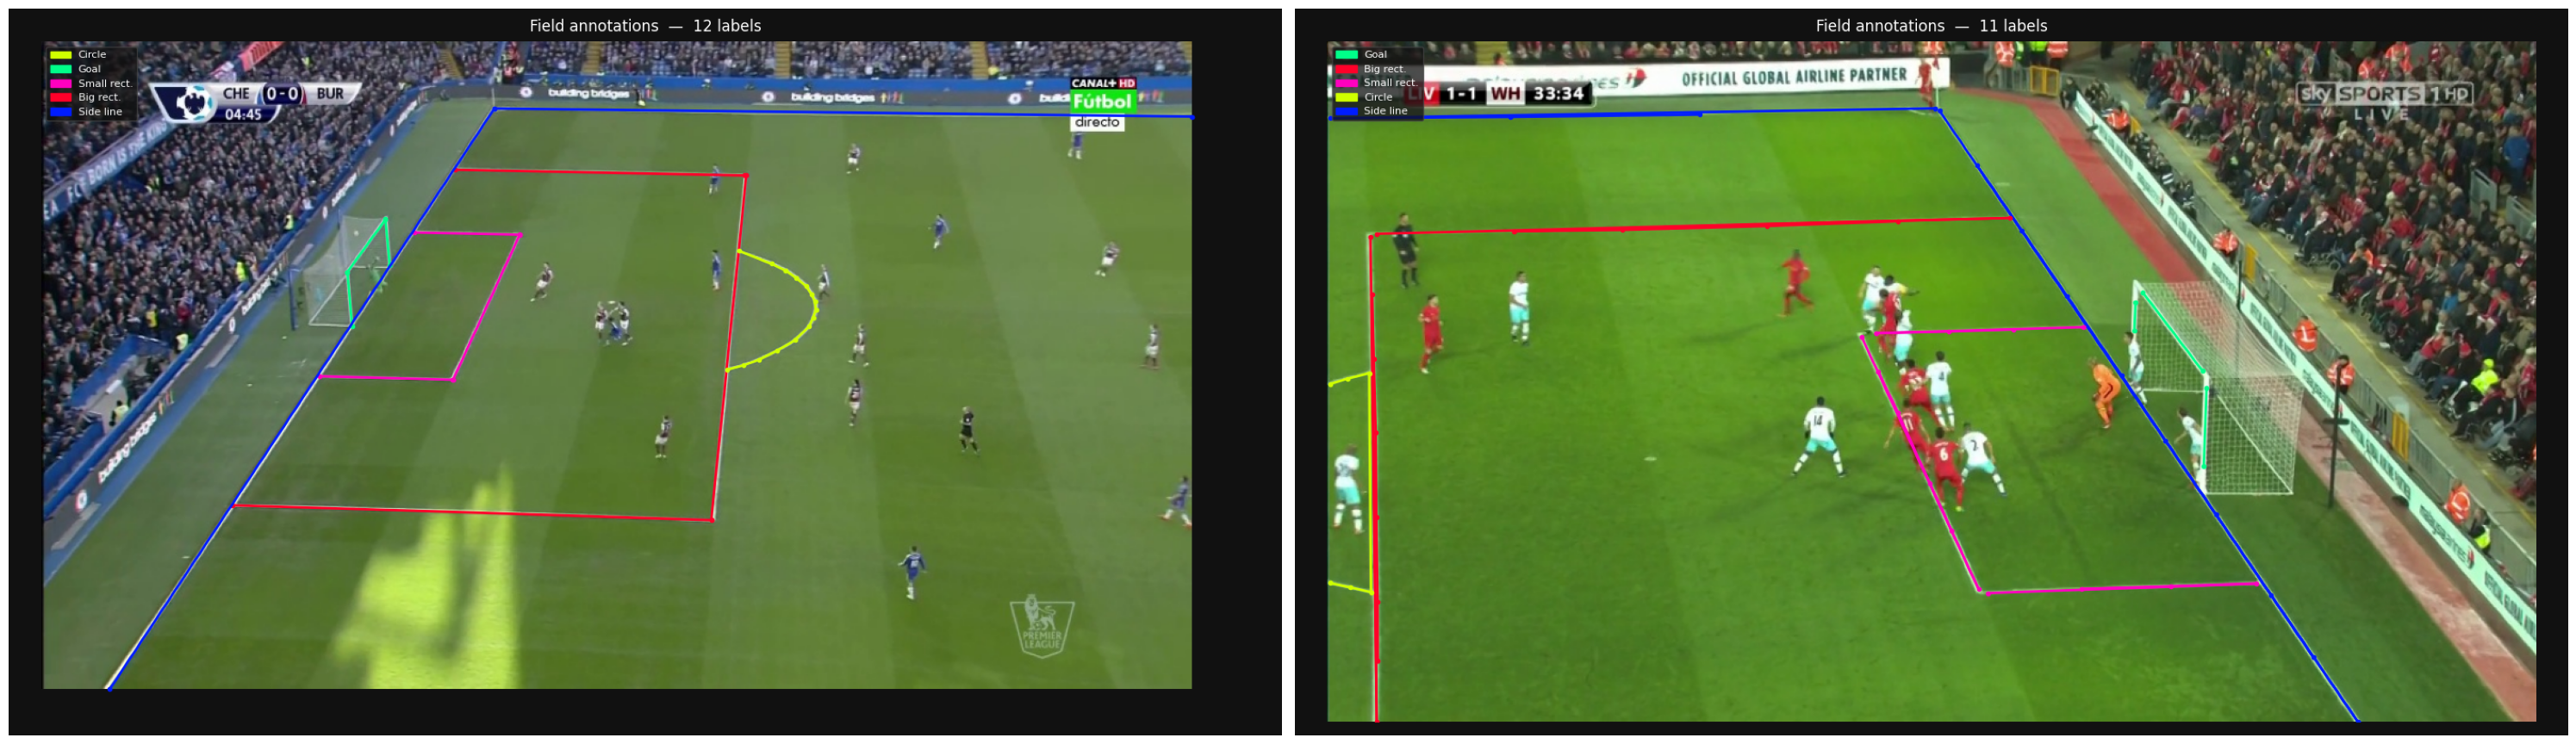

In [9]:
from ia_futbol.utils.image_tools import display_image
from ia_futbol.utils.image_tools import display_images
import os

img_sample= [os.path.join(soccernet_path,"train","00001.jpg"),os.path.join(soccernet_path,"train","03066.jpg")]
label_sample = [img.replace(".jpg",".json") for img in img_sample]

imgs = [draw_field_lines(image_path=img,json_source=label) for img,label in zip(img_sample,label_sample)]

display_images(imgs,rows=1,cols=2)


Para lograr una localización precisa de las entidades dentro del terreno de juego, hemos desarrollado un conjunto de datos basado en **57 puntos clave (keypoints)**. Estos puntos actúan como un sistema de coordenadas de referencia, permitiendo mapear la imagen bidimensional con el espacio tridimensional del campo.

La obtención de estos puntos se divide en cuatro categorías según su método de cálculo:

1. **Intersecciones Geométricas (Puntos Rojos y Azules)** La base de nuestra malla de referencia se construye a partir de los segmentos de línea proporcionados por el dataset de **SoccerNet**. Mediante el cálculo de las intersecciones entre estos segmentos (como el cruce de las líneas de banda con las de fondo o las áreas), se definen los puntos estructurales primarios.

2. **Rectas Tangenciales (Puntos Morados)** Para las zonas curvas del campo, específicamente el círculo central y las áreas de castigo (semicírculos de los bordes del área grande), los puntos se obtienen mediante el cálculo de **rectas tangenciales**. Esto permite fijar referencias precisas en elementos que no presentan vértices naturales.

3. **Homografías y Proyecciones (Puntos Verdes y Negros)** En aquellas zonas donde no existe una intersección física de líneas visibles, empleamos técnicas de **homografía**. Utilizando la posición de los puntos previamente calculados y conociendo la geometría proyectiva de la cámara, somos capaces de inferir la ubicación exacta de estos puntos adicionales en el plano de la imagen.

4. **Precisión Matemática mediante Medidas Oficiales** Dado que las dimensiones de un terreno de juego profesional están estandarizadas por la normativa internacional, conocemos las distancias reales entre cada elemento. Esto nos permite:
   * **Validar** la precisión de los 57 puntos extraídos.
   * **Calcular** la posición exacta que debería ocupar cada punto en un modelo de vista cenital (*top-down*).
   * **Garantizar** que el sistema de referencia sea robusto frente a cambios de perspectiva o distorsión de lente.



<p align="center">
  <img src="/home/adrian/IA-Futbol/images/pitch_pattern.jpg" width="800" alt="Pitch Pattern Keypoints">
</p>

In [ ]:
import numpy as np
import os
from ia_futbol.utils.pitch import draw_pitch
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

NUM_KEYPOINTS = 57

def read_labels(txt : str):
    #txt path to label.txt

    count = np.zeros(NUM_KEYPOINTS) #Vector de ceros 

    with open(txt) as f:

        for line in f:
            line = line.split() #clase
            if line : # "[]" se evalua como False
                count[int(line[0])] +=1

    return count

def keypoint_count(set_path:str):

    #Cuenta el numero de veces que aparece cada tipo de punto

    count = np.zeros(NUM_KEYPOINTS)

    labels = os.listdir(os.path.join(set_path,"labels"))

    for label in labels:

        count += read_labels(os.path.join(set_path,"labels",label))

    return count


/tmp/ipykernel_13201/3410796726.py:21: RuntimeWarning: invalid value encountered in scalar divide
  ax.text(x, y + 1.8, f"{counts[id]/total * 100:.2f}%", color='white', fontsize=8,


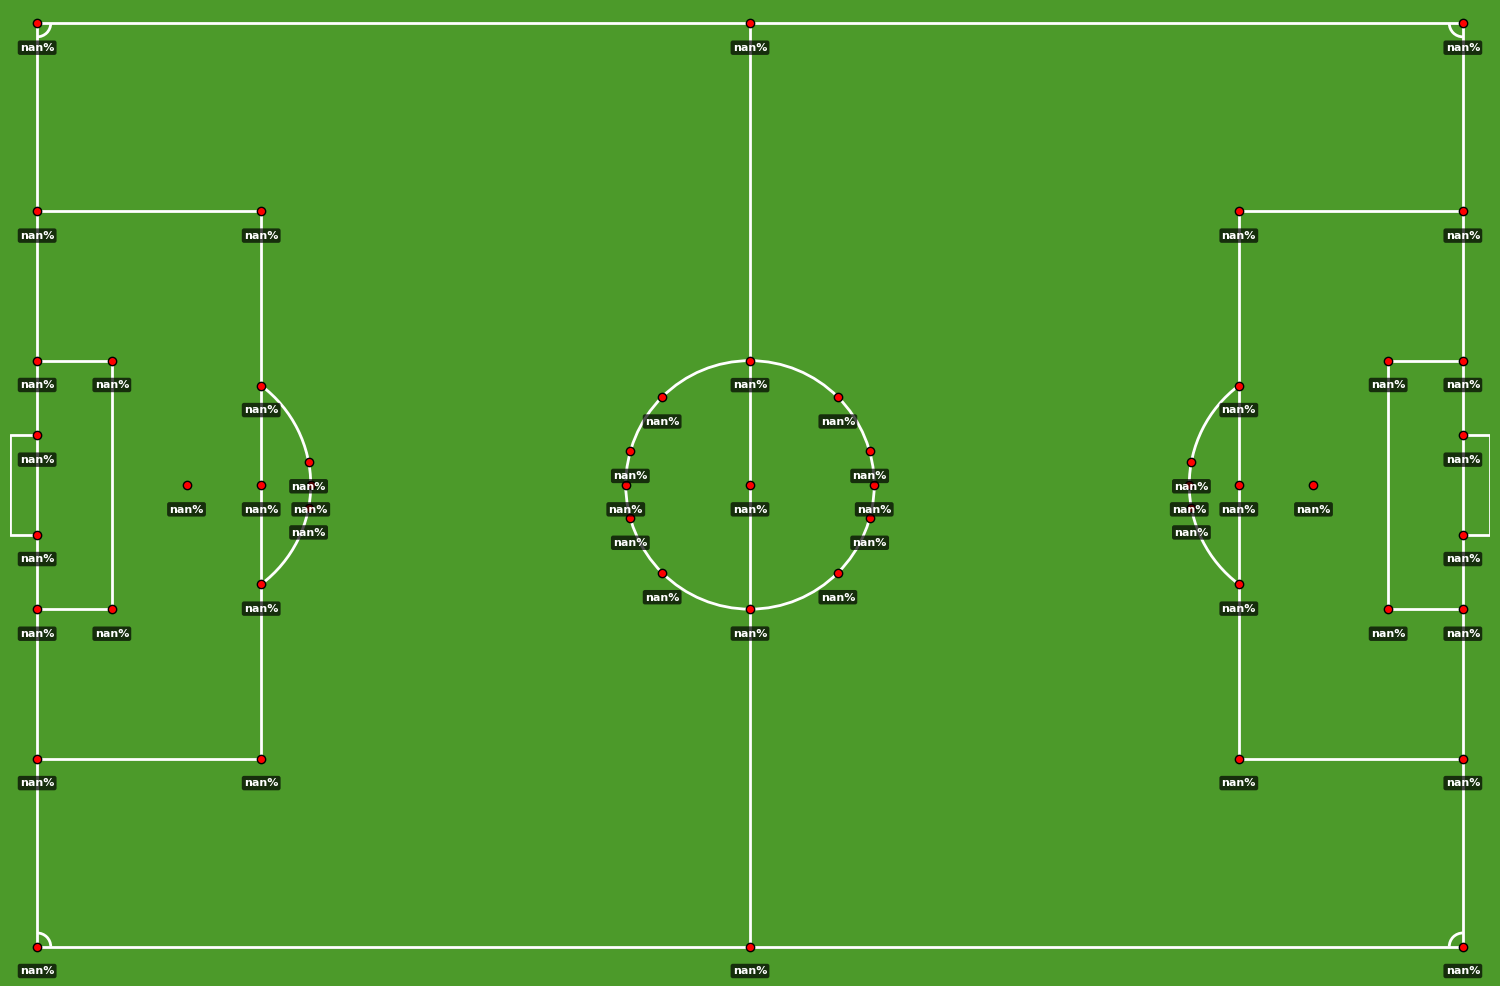

In [4]:
from pitch_keypoints.ellipse import PITCH_POINTS
from pitch_keypoints.ellipse import INTERSECTON_TO_PITCH_POINTS
from utils.config import PITCH_KEYPOINTS_DATA

counts = keypoint_count(os.path.join(PITCH_KEYPOINTS_DATA,"train"))
total = counts.sum()

fig, ax = draw_pitch(figsize=(14.8,12.8))
# Eliminar márgenes automáticos

for id, cls in INTERSECTON_TO_PITCH_POINTS.items():

    cls = INTERSECTON_TO_PITCH_POINTS[id] 

    if  cls != "L_GOAL_TL_POST" and cls != "L_GOAL_TR_POST" and cls !="R_GOAL_TL_POST" and cls != "R_GOAL_TR_POST":

        x,y,_ = PITCH_POINTS[cls]
        
        ax.plot(x, y, "o", color="red", markersize=6, zorder=3, markeredgecolor='black')
        # Etiqueta con fondo oscuro
        ax.text(x, y + 1.8, f"{counts[id]/total * 100:.2f}%", color='white', fontsize=8, 
                ha='center', va='center', zorder=4, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2', edgecolor='none'))


# Ajuste fino final

plt.show()

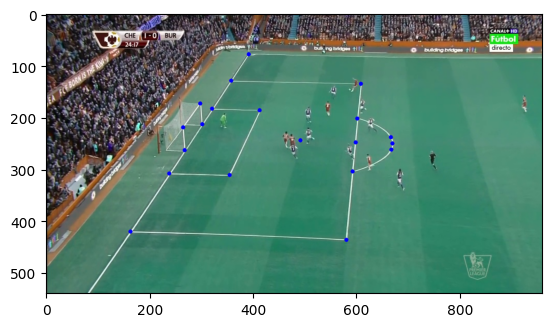

In [3]:
import cv2
import matplotlib.pyplot as plt
img = os.path.join("dataset","train","images","00011.jpg")
path = os.path.join("dataset","train","labels","00011.txt")
    
img = cv2.imread(img)
h,w,c = img.shape


with open(path,"r") as f:

    for line in f:
        
        line = line.split()
        x = int(float(line[1]) * w)
        y = int(float(line[2]) * h)

        # Dibujamos el círculo
        cv2.circle(img, (x, y), 4, (0, 0, 255),-1)

plt.imshow(img)
plt.show()
